In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving EPL - 24-25.csv to EPL - 24-25.csv
Saving EPL -25-26.csv to EPL -25-26.csv
Saving europa conference 25-26.csv to europa conference 25-26.csv
Saving Europa conference league 24-25.csv to Europa conference league 24-25.csv
Saving La Liga 25-26.csv to La Liga 25-26.csv
Saving La liga simple - 24-25.csv to La liga simple - 24-25.csv
User uploaded file "EPL - 24-25.csv" with length 3696 bytes
User uploaded file "EPL -25-26.csv" with length 3581 bytes
User uploaded file "europa conference 25-26.csv" with length 4776 bytes
User uploaded file "Europa conference league 24-25.csv" with length 4479 bytes
User uploaded file "La Liga 25-26.csv" with length 3482 bytes
User uploaded file "La liga simple - 24-25.csv" with length 3650 bytes


In [ ]:
import pandas as pd
import numpy as np
import io

# Step 1: Data cleaned in excel but might need to be transformed since we changed excel to csv
file1 = pd.read_csv(io.BytesIO(uploaded['EPL - 24-25.csv']), sep=';')
file2 = pd.read_csv(io.BytesIO(uploaded['EPL -25-26.csv']), sep=';')
file3 = pd.read_csv(io.BytesIO(uploaded['europa conference 25-26.csv']), sep=';')
file4 = pd.read_csv(io.BytesIO(uploaded['Europa conference league 24-25.csv']), sep=';')
file5 = pd.read_csv(io.BytesIO(uploaded['La liga simple - 24-25.csv']), sep=';')
file6 = pd.read_csv(io.BytesIO(uploaded['La Liga 25-26.csv']), sep=';')

# 2. All tables formatted the same for easy analysis
Columns = ['Home', 'Away', 'Goals(For)', 'Goals(Against)', 'Winner']
file1.columns = Columns
file2.columns = Columns
file3.columns = Columns
file4.columns = Columns
file5.columns = Columns
file6.columns = Columns

# 3. Combine all files to make analysis on crystal palace easier
df_master = pd.concat([file1, file2, file3, file4, file5, file6], ignore_index=True)

# 4. Last clean up just in case
df_master = df_master.dropna()
df_master['Home'] = df_master['Home'].str.strip()
df_master['Away'] = df_master['Away'].str.strip()
df_master['Winner'] = df_master['Winner'].str.strip().str.lower()

print("Crystal palace predictive analysis data!")

Crystal palace predictive analysis data!


In [ ]:
#PREDICTIVE ANALYSIS
# How did the home teams fair
home_stats = df_master.groupby('Home').agg(
    Home_Matches=('Home', 'count'),
    Home_Goals_Scored=('Goals(For)', 'sum'),
    Home_Goals_Conceded=('Goals(Against)', 'sum')
)

# How did the away teams fair
away_stats = df_master.groupby('Away').agg(
    Away_Matches=('Away', 'count'),
    Away_Goals_Scored=('Goals(Against)', 'sum'),
    Away_Goals_Conceded=('Goals(For)', 'sum')
)

# Combine home and away stats into Combined Team analysis
CombinedTeamAnalysis = home_stats.join(away_stats, how='outer').fillna(0)

# what are the usual averages
total_matches = CombinedTeamAnalysis['Home_Matches'] + CombinedTeamAnalysis['Away_Matches']
CombinedTeamAnalysis['Avg_Goals_Scored'] = (CombinedTeamAnalysis['Home_Goals_Scored'] + CombinedTeamAnalysis['Away_Goals_Scored']) / total_matches
CombinedTeamAnalysis['Avg_Goals_Conceded'] = (CombinedTeamAnalysis['Home_Goals_Conceded'] + CombinedTeamAnalysis['Away_Goals_Conceded']) / total_matches

# Final data should only show averages
df_profiles = CombinedTeamAnalysis[['Avg_Goals_Scored', 'Avg_Goals_Conceded']]
print("Home and Away team analysis")

Home and Away team analysis


Training Logistic Regression...
Model Training Done for Logistic Regression! Test Accuracy: 68.817%
Training Decision Tree...
Model Training Done for Decision Tree! Test Accuracy: 59.857%
Training Random Forest...
Model Training Done for Random Forest! Test Accuracy: 59.140%
Training Gradient Boosting...
Model Training Done for Gradient Boosting! Test Accuracy: 57.348%


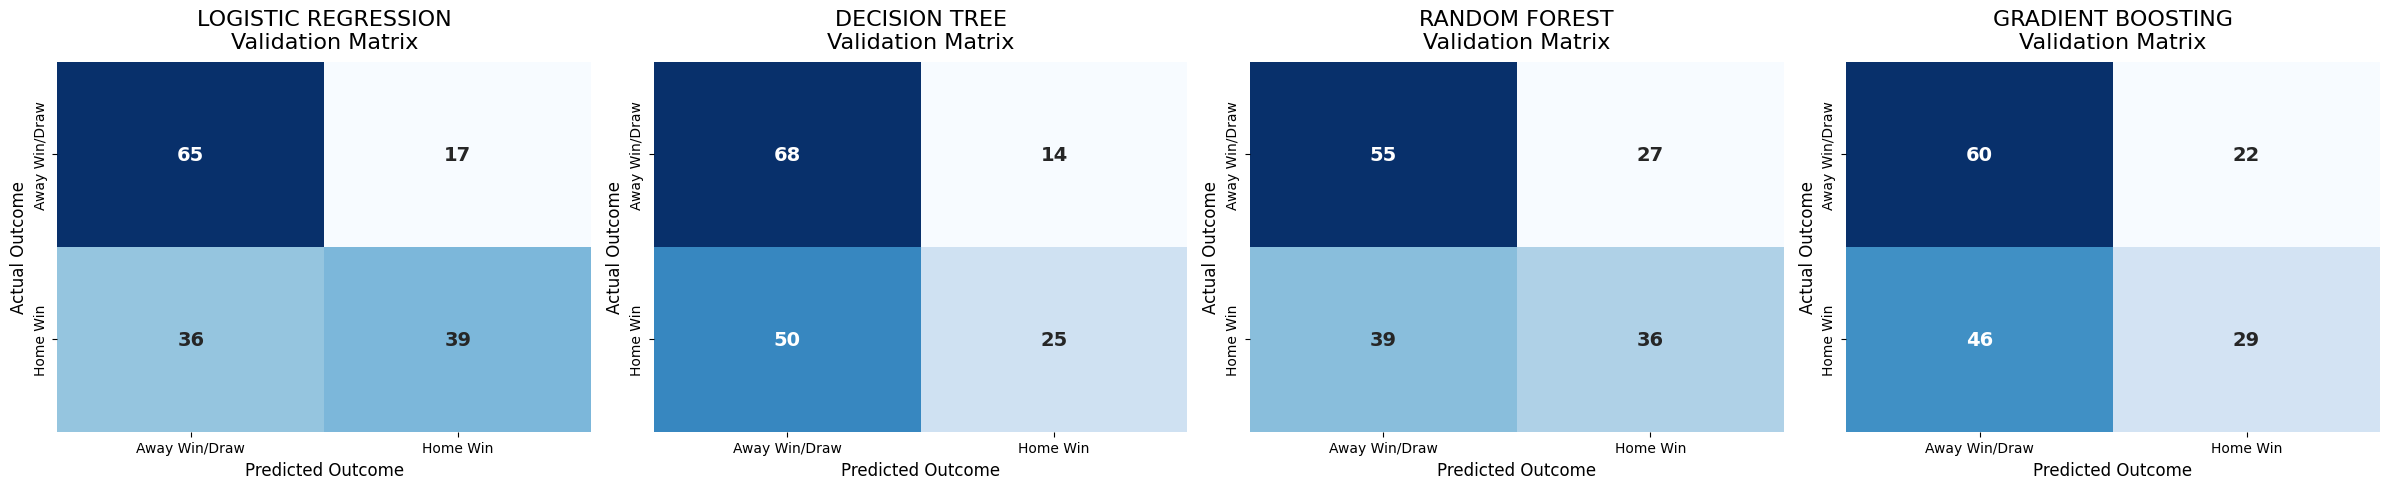

Decision Tree Test Accuracy,▁
Gradient Boosting Test Accuracy,▁
Logistic Regression Test Accuracy,▁
Model Accuracy Slices/Gradient Boosting,▁
Random Forest Test Accuracy,▁
Decision Tree Test Accuracy,0.59857
Gradient Boosting Test Accuracy,0.57348
Logistic Regression Test Accuracy,0.68817
Model Accuracy Slices/Gradient Boosting,0.57348
Random Forest Test Accuracy,0.5914


In [ ]:
#We will use different predictive analysis tools to ensure we get a good working model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import numpy as np

X = []
y = []

# Training parameters
for idx, row in df_master.iterrows():
    home_team = row['Home']
    away_team = row['Away']

    if home_team in df_profiles.index and away_team in df_profiles.index:
        # Difference between Home team and Away team
        stat_difference = df_profiles.loc[home_team] - df_profiles.loc[away_team]
        X.append(stat_difference.values)

        # Goal: 1 if Home team won, 0 if Draw or Away win
        if 'home win' in row['Winner']:
            y.append(1)
        else:
            y.append(0)

X = np.array(X)
y = np.array(y)

# Data split into training, validation, and testing sets
# Weights and bases does accept splitting data in 3 like sas viya, so for this i have to split it twice, to achieve the needed calculations.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Final split  training(60%), testing(25%) and validation(15%) data(Can not have a model that can not be validated)
X_train, X_val, y_train, y_Val = train_test_split(X_temp, y_temp, test_size=0.375, random_state=42)

# Start Weights & Biases for this run
run = wandb.init(project="uefaconferenceleaue-final-simulation", name="Possibility of a win - Multiple Models")

trained_models = {}

# Models to  be trained(to ensure best model chosen)
models_to_train = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Model training: Loop each model, train, evaluate, and log accuracy
for model_name, model_instance in models_to_train.items():
    print(f"Training {model_name}...")
    model_instance.fit(X_train, y_train)
    trained_models[model_name] = model_instance

    # Calculate accuracy score using the test data
    accuracy = model_instance.score(X_test, y_test)
    print(f"Model Training Done for {model_name}! Test Accuracy: {accuracy:.3%}")

    # Send the accuracy value to your W&B online dashboard
    wandb.log({f"{model_name} Test Accuracy": accuracy})


# Confusion Matrix plotting logic (re-added from deleted cell and fixed)
if 'trained_models' in locals() and 'X_val' in locals() and 'y_Val' in locals():

    num_models = len(trained_models)
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))

    if num_models == 1:
        axes = [axes]

    for idx, (model_name, model_object) in enumerate(trained_models.items()):

        val_predictions = model_object.predict(X_val)
        cm = confusion_matrix(y_Val, val_predictions)

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Away Win/Draw', 'Home Win'],
            yticklabels=['Away Win/Draw', 'Home Win'],
            cbar=False,
            ax=axes[idx],
            annot_kws={"size": 14, "weight": "bold"}
        )

        axes[idx].set_title(f'{model_name.upper()}\nValidation Matrix', fontsize=16, pad=10)
        axes[idx].set_ylabel('Actual Outcome', fontsize=12)
        axes[idx].set_xlabel('Predicted Outcome', fontsize=12)

    plt.tight_layout()
    plt.show()
    wandb.log({"Confusion Matrix": wandb.Image(fig)})
    wandb.log({f"Model Accuracy Slices/{model_name}": accuracy})
    plt.close(fig)

else:
    print("Error: Missing trained_models, X_val, or y_Val for confusion matrix plotting.")


run.finish()


In [ ]:
#Final Model Selection(Based on our Accuracy scores)
chosen_model = trained_models['Logistic Regression']

# Teams finally singled out from data sets
palace_name = [name for name in df_profiles.index if "Palace" in name][0]
rayo_name = [name for name in df_profiles.index if "Rayo" in name][0]

# prediction analysis run
final_match_features = (df_profiles.loc[palace_name] - df_profiles.loc[rayo_name]).values.reshape(1, -1)
palace_win_chance = chosen_model.predict_proba(final_match_features)[0][1]

print(f"=== FINAL MATCH PROBABILITY ({chosen_model.__class__.__name__}) ===")
print(f"{palace_name} Win Chance: {palace_win_chance:.1%}")
print(f"{rayo_name} Win or Draw Chance: {(1 - palace_win_chance):.1%}")

=== FINAL MATCH PROBABILITY (LogisticRegression) ===
Crystal Palace Win Chance: 37.8%
Rayo Vallecano Win or Draw Chance: 62.2%
